   cgpa  placement_exam_marks college_tier  internship_experience  placement
0  7.19                  26.0       Tier 2                      1          0
1  7.46                  38.0       Tier 3                      1          1
2  7.54                  40.0       Tier 1                      0          0
3  6.42                   8.0       Tier 3                      0          1
4  7.23                  17.0       Tier 2                      0          1
      cgpa  placement_exam_marks college_tier  internship_experience  \
1245  9.21                 24.13       Tier 2                      1   
1246  7.21                 33.35       Tier 2                      1   
1247  9.37                 13.11       Tier 2                      0   
1248  9.35                 48.98       Tier 2                      1   
1249  8.91                 49.45       Tier 2                      1   

      placement  
1245          0  
1246          1  
1247          0  
1248          1  
1249          1

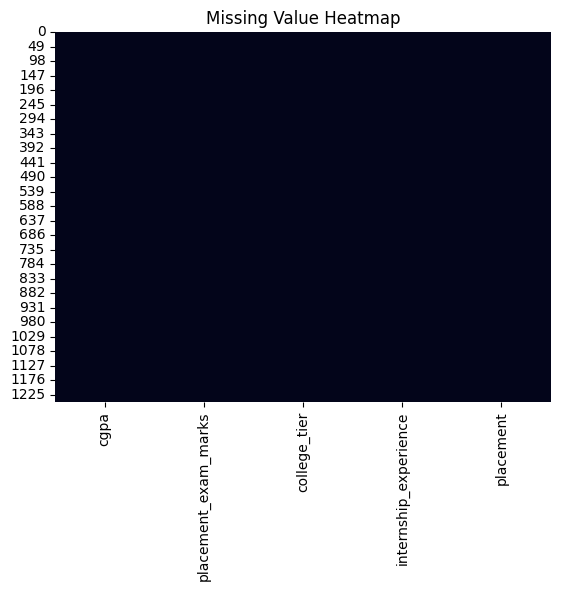

cgpa                     0
placement_exam_marks     0
college_tier             0
internship_experience    0
placement                0
dtype: int64
{0: 'Not Placed', 1: 'Placed'}
   placement placement_label
0          0      Not Placed
1          1          Placed
2          0      Not Placed
3          1          Placed
4          1          Placed


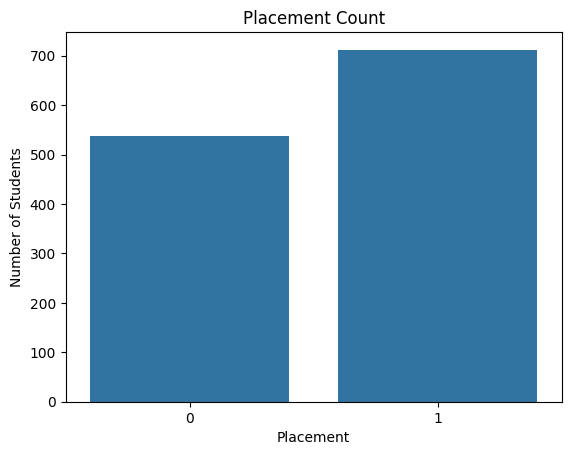

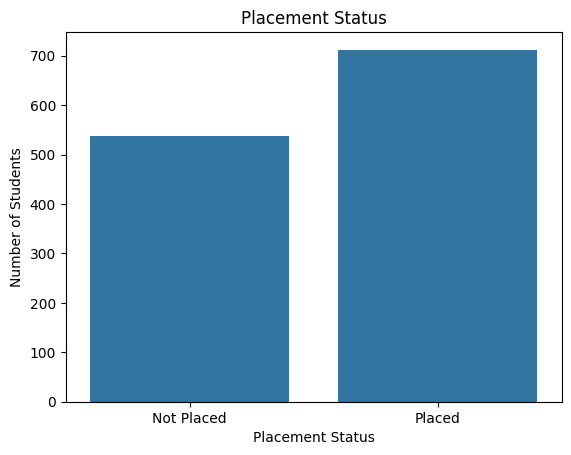

placement
1    712
0    538
Name: count, dtype: int64
Overall Placement Rate:
0.5696
Average CGPA by Placement Status:
placement_label
Not Placed    6.914963
Placed        7.171882
Name: cgpa, dtype: float64


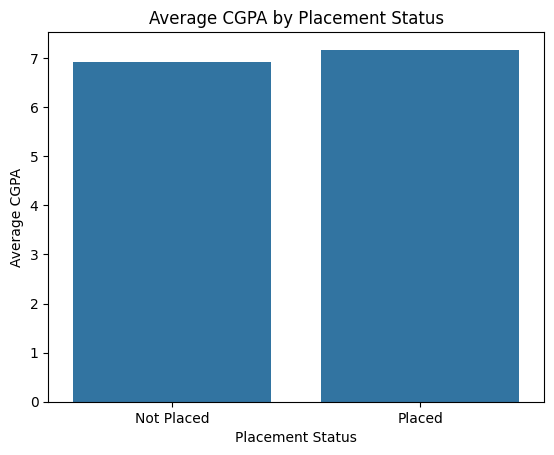

Average Placement Exam Marks by Placement Status:
placement_label
Not Placed    32.392212
Placed        31.411517
Name: placement_exam_marks, dtype: float64


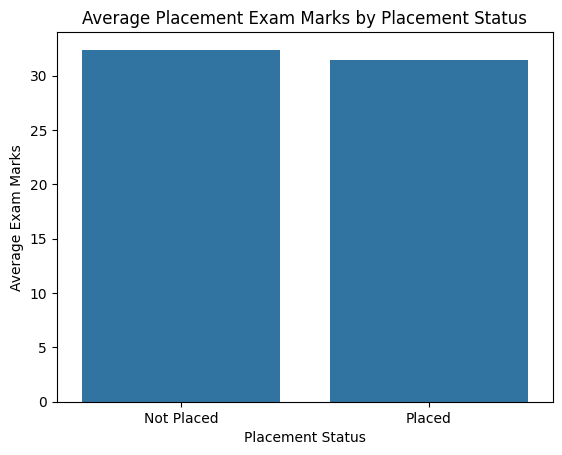

Placement Rate by CGPA Range:
cgpa_range
Below 6    0.510870
6-7        0.505515
7-8        0.586864
8-9        0.800000
9-10       0.783784
Name: placement, dtype: float64


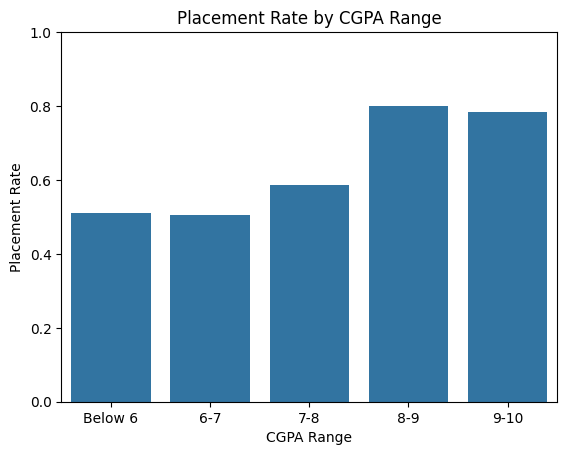

Placement Rate by Exam Marks:
exam_marks_range
Below 40    0.584181
40-50       0.539683
50-60       0.567901
60-70       0.461538
70-80       0.521739
80-100      0.526316
Name: placement, dtype: float64


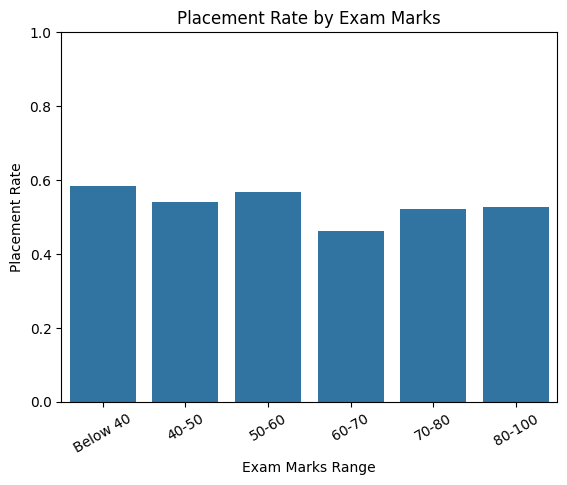

Correlation Matrix:
                          cgpa  placement_exam_marks  placement
cgpa                  1.000000             -0.034174   0.160891
placement_exam_marks -0.034174              1.000000  -0.027066
placement             0.160891             -0.027066   1.000000


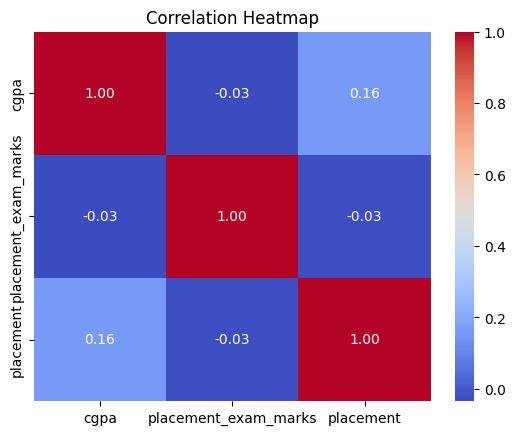

PDF created successfully
placement_eda_report.pdf


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

df = pd.read_csv("/content/placement.csv")

print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)

print(df.info())
print(df.describe())
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

df["cgpa"] = df["cgpa"].fillna(df["cgpa"].median())
df["placement"] = df["placement"].fillna(df["placement"].median())
df["placement"] = df["placement"].fillna(df["placement"].mode()[0])

print(df.isnull().sum())

placement_mapping = {
    0: "Not Placed",
    1: "Placed"
}

df["placement_label"] = df["placement"].map(placement_mapping)

print(placement_mapping)
print(df[["placement", "placement_label"]].head())

sns.countplot(x="placement", data=df)
plt.title("Placement Count")
plt.xlabel("Placement")
plt.ylabel("Number of Students")
plt.show()

sns.countplot(x="placement_label", data=df)
plt.title("Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

print(df["placement"].value_counts())

placement_rate = df["placement"].mean()

print("Overall Placement Rate:")
print(placement_rate)

cgpa_placement = df.groupby("placement_label")["cgpa"].mean()

print("Average CGPA by Placement Status:")
print(cgpa_placement)

sns.barplot(x=cgpa_placement.index, y=cgpa_placement.values)
plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.show()

exam_placement = df.groupby("placement_label")["placement_exam_marks"].mean()

print("Average Placement Exam Marks by Placement Status:")
print(exam_placement)

sns.barplot(x=exam_placement.index, y=exam_placement.values)
plt.title("Average Placement Exam Marks by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Exam Marks")
plt.show()

df["cgpa_range"] = pd.cut(
    df["cgpa"],
    bins=[0, 6, 7, 8, 9, 10],
    labels=["Below 6", "6-7", "7-8", "8-9", "9-10"]
)

cgpa_analysis = df.groupby("cgpa_range", observed=False)["placement"].mean()

print("Placement Rate by CGPA Range:")
print(cgpa_analysis)

sns.barplot(x=cgpa_analysis.index, y=cgpa_analysis.values)
plt.title("Placement Rate by CGPA Range")
plt.xlabel("CGPA Range")
plt.ylabel("Placement Rate")
plt.ylim(0, 1)
plt.show()

df["exam_marks_range"] = pd.cut(
    df["placement_exam_marks"],
    bins=[0, 40, 50, 60, 70, 80, 100],
    labels=["Below 40", "40-50", "50-60", "60-70", "70-80", "80-100"]
)

exam_analysis = df.groupby("exam_marks_range", observed=False)["placement"].mean()

print("Placement Rate by Exam Marks:")
print(exam_analysis)

sns.barplot(x=exam_analysis.index, y=exam_analysis.values)
plt.title("Placement Rate by Exam Marks")
plt.xlabel("Exam Marks Range")
plt.ylabel("Placement Rate")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

correlation = df[["cgpa", "placement_exam_marks", "placement"]].corr()

print("Correlation Matrix:")
print(correlation)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

pdf = PdfPages("placement_eda_report.pdf")

fig = plt.figure(figsize=(8.27, 11.69))

plt.subplot(2, 1, 1)
plt.axis("off")
plt.text(
    0,
    1,
    "PLACEMENT DATASET EDA REPORT\n\n"
    + "Dataset Shape: "
    + str(df.shape)
    + "\n\nFirst 5 Rows:\n\n"
    + df.head().to_string(index=False),
    fontsize=9,
    verticalalignment="top"
)

plt.subplot(2, 1, 2)
sns.heatmap(df[["cgpa", "placement_exam_marks", "placement"]].isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Heatmap")

plt.tight_layout()
pdf.savefig(fig)
plt.close()

fig = plt.figure(figsize=(8.27, 11.69))

plt.subplot(2, 1, 1)
sns.countplot(x="placement_label", data=df)
plt.title("Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.subplot(2, 1, 2)
sns.barplot(x=cgpa_placement.index, y=cgpa_placement.values)
plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")

plt.tight_layout()
pdf.savefig(fig)
plt.close()

fig = plt.figure(figsize=(8.27, 11.69))

plt.subplot(2, 1, 1)
sns.barplot(x=exam_placement.index, y=exam_placement.values)
plt.title("Average Placement Exam Marks by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Exam Marks")

plt.subplot(2, 1, 2)
sns.barplot(x=cgpa_analysis.index, y=cgpa_analysis.values)
plt.title("Placement Rate by CGPA Range")
plt.xlabel("CGPA Range")
plt.ylabel("Placement Rate")
plt.ylim(0, 1)

plt.tight_layout()
pdf.savefig(fig)
plt.close()

fig = plt.figure(figsize=(8.27, 11.69))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Placement Dataset Correlation Heatmap")

plt.tight_layout()
pdf.savefig(fig)
plt.close()

pdf.close()

print("PDF created successfully")
print("placement_eda_report.pdf")